# Imports

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


## Get data

In [2]:
def mean_std_over_seeds(curves_by_seed):
    """
    curves_by_seed: dict {seed: array of shape (n_train_sizes,)}
    """
    Y = np.stack(list(curves_by_seed.values()), axis=0)
    return Y.mean(axis=0), Y.std(axis=0)


In [3]:
# train_mse[seed] : shape (n_train_sizes, n_lambdas)
# test_mse[seed]  : shape (n_train_sizes, n_lambdas)


In [4]:
def load_best_lambda_curves(pkl_path, best_lambda):
    with open(pkl_path, "rb") as f:
        obj = pickle.load(f)

    train_sizes = obj["train_sizes"]
    lambdas = np.array(obj["lambdas"])
    li = np.where(lambdas == best_lambda)[0][0]

    train_curves = {s: obj["results"][s]["train_mse"][:, li] for s in obj["seeds"]}
    test_curves  = {s: obj["results"][s]["test_mse"][:, li]  for s in obj["seeds"]}

    train_mean, train_std = mean_std_over_seeds(train_curves)
    test_mean,  test_std  = mean_std_over_seeds(test_curves)

    gap_mean = test_mean - train_mean
    gap_std  = np.sqrt(train_std**2 + test_std**2)

    return {
        "train_sizes": train_sizes,
        "train_mean": train_mean,
        "train_std": train_std,
        "test_mean": test_mean,
        "test_std": test_std,
        "gap_mean": gap_mean,
        "gap_std": gap_std,
    }


In [5]:
def load_best_gaussian_curves(pkl_path, best_sigma_label, best_lambda):
    with open(pkl_path, "rb") as f:
        obj = pickle.load(f)

    train_sizes = obj["train_sizes"]
    lambdas = np.array(obj["lambdas"])
    li = np.where(lambdas == best_lambda)[0][0]

    train_curves = {}
    test_curves  = {}

    for seed in obj["seeds"]:
        entry = obj["results"][seed][best_sigma_label]
        train_curves[seed] = entry["train_mse"][:, li]
        test_curves[seed]  = entry["test_mse"][:, li]

    train_mean, train_std = mean_std_over_seeds(train_curves)
    test_mean,  test_std  = mean_std_over_seeds(test_curves)

    gap_mean = test_mean - train_mean
    gap_std  = np.sqrt(train_std**2 + test_std**2)

    return {
        "train_sizes": train_sizes,
        "train_mean": train_mean,
        "train_std": train_std,
        "test_mean": test_mean,
        "test_std": test_std,
        "gap_mean": gap_mean,
        "gap_std": gap_std,
    }


# Transverse Ising Hamiltonian

## Comparing different methods(2 Qubits)

In [6]:

method_ood = {
    "2 Qubits 1 step no bound": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1stepnobound.pkl", 0.001
    ),
    "2 Qubits 1 step bounded warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1step.pkl", 0.001
    ),
    "2 Qubits 1 step bounded no warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1stepnowarm.pkl", 0.001
    ),
    "2 Qubits 1 step bounded bad warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_twoqubit1stepbadwarm.pkl", 0.001
    ),

   
}

### Test Error

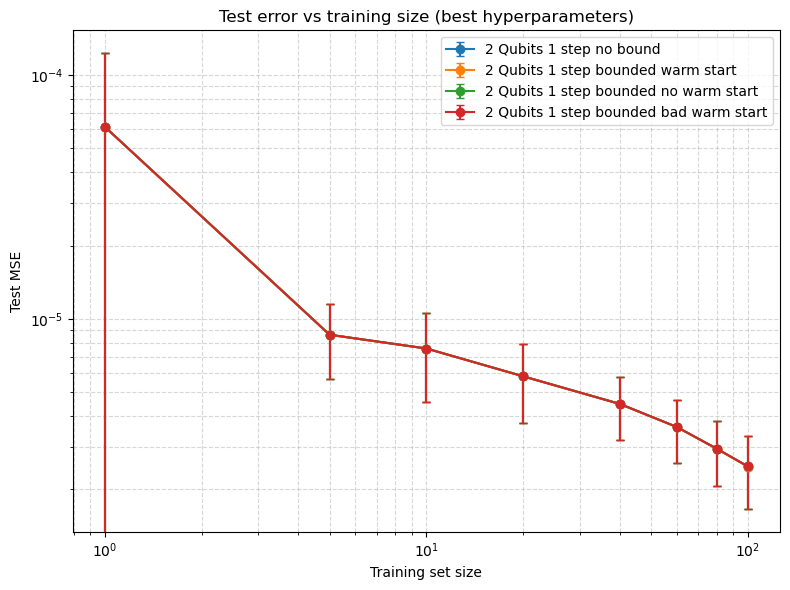

In [7]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [8]:
for name, res in method_ood.items():
    print(res["test_std"])

[6.16602777e-05 2.93179774e-06 3.00827438e-06 2.06339224e-06
 1.29398336e-06 1.04121373e-06 8.76068528e-07 8.24092505e-07]
[6.16602777e-05 2.93179774e-06 3.00827438e-06 2.06339224e-06
 1.29398336e-06 1.04121373e-06 8.76068528e-07 8.24092505e-07]
[6.16602777e-05 2.93552905e-06 3.00831035e-06 2.06339226e-06
 1.29398333e-06 1.04121381e-06 8.77017146e-07 8.25794425e-07]
[6.16602777e-05 2.93552905e-06 3.00831035e-06 2.06339226e-06
 1.29398333e-06 1.04121381e-06 8.77017146e-07 8.25794425e-07]


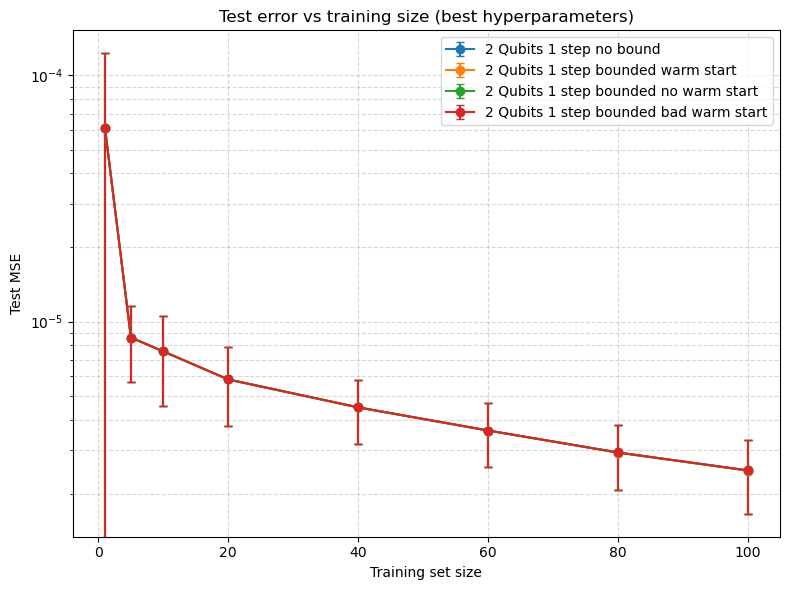

In [9]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


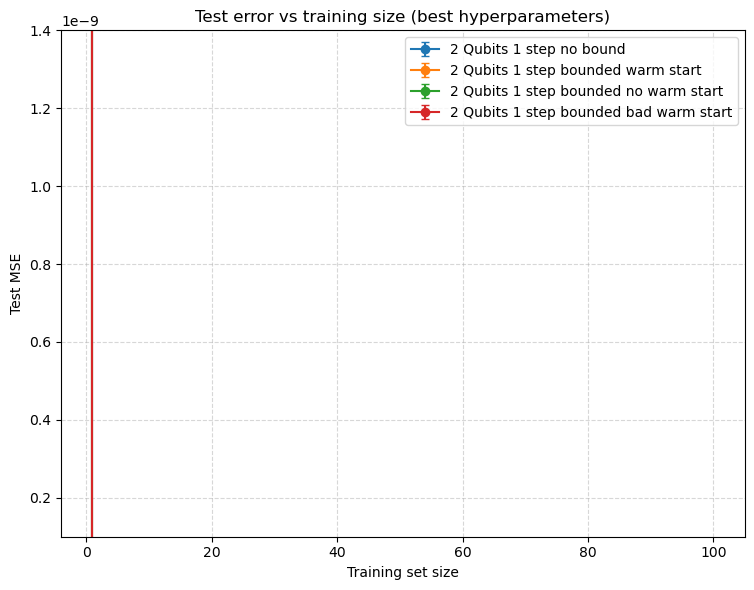

In [10]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(1e-10,1.4e-9)
plt.show()


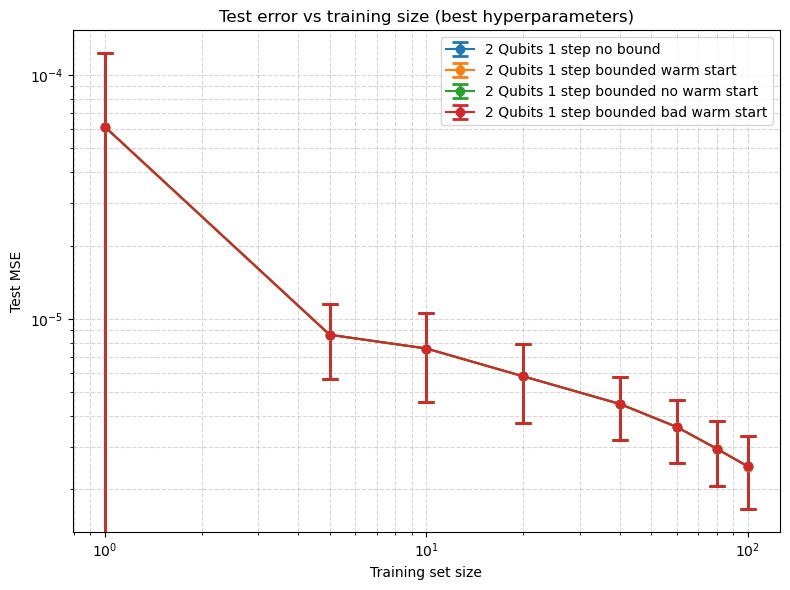

In [11]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=6,
        elinewidth=2,
        capthick=2,
        label=name
    )


plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Generalization Gap

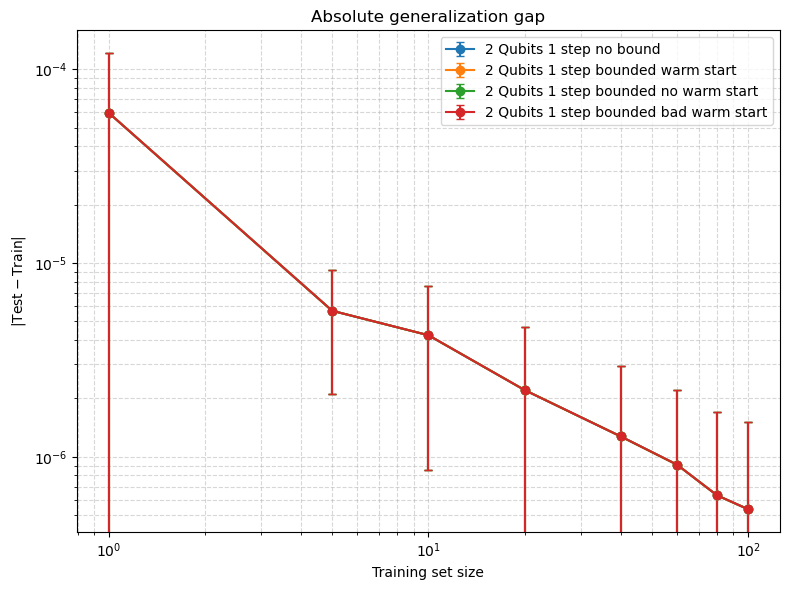

In [12]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

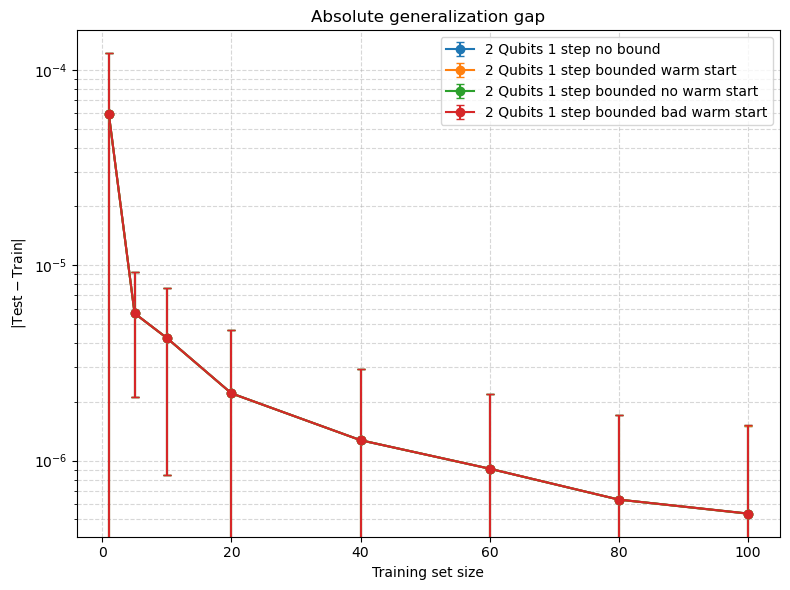

In [13]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Comparing different methods(3 Qubits)

In [14]:

method_ood = {
    "3 Qubits 1 step no bound": load_best_lambda_curves(
        "results/mse_results_TIHP_threequbit1stepnobound.pkl", 0.001
    ),
    "3 Qubits 1 step bounded warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_threequbit1step.pkl", 0.001
    ),
    "3 Qubits 1 step bounded no warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_threequbit1stepnowarm.pkl", 0.001
    ),
    "3 Qubits 1 step bounded bad warm start": load_best_lambda_curves(
        "results/mse_results_TIHP_threequbit1stepbadwarm.pkl", 0.001
    ),
   
}

### Test Error

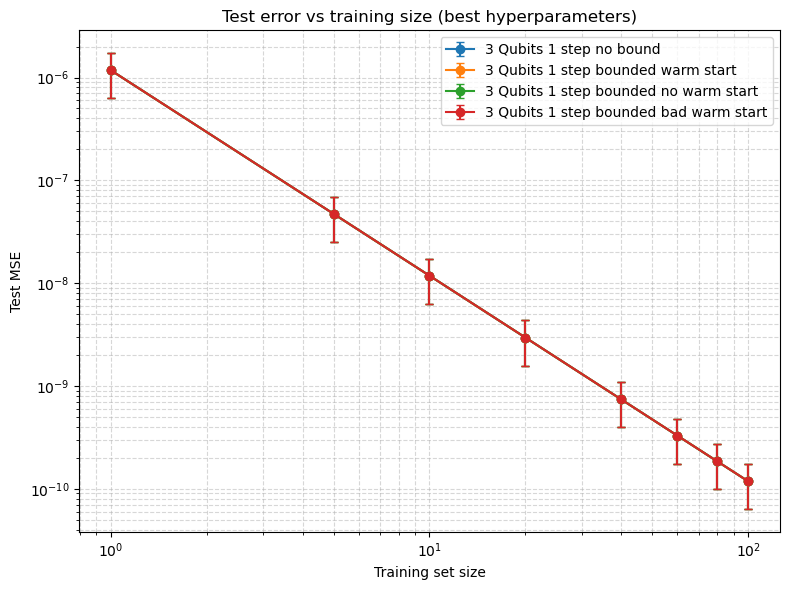

In [15]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [16]:
for name, res in method_ood.items():
    print(res["test_std"])

[5.49241728e-07 2.20400001e-08 5.51220381e-09 1.37832655e-09
 3.44616095e-10 1.53167814e-10 8.61583313e-11 5.51418834e-11]
[5.49241728e-07 2.20400001e-08 5.51220381e-09 1.37832655e-09
 3.44616095e-10 1.53167814e-10 8.61583313e-11 5.51418834e-11]
[5.49241728e-07 2.20400001e-08 5.51220381e-09 1.37832655e-09
 3.44616095e-10 1.53167814e-10 8.61583313e-11 5.51418834e-11]
[5.49241728e-07 2.20400001e-08 5.51220381e-09 1.37832655e-09
 3.44616095e-10 1.53167814e-10 8.61583313e-11 5.51418834e-11]


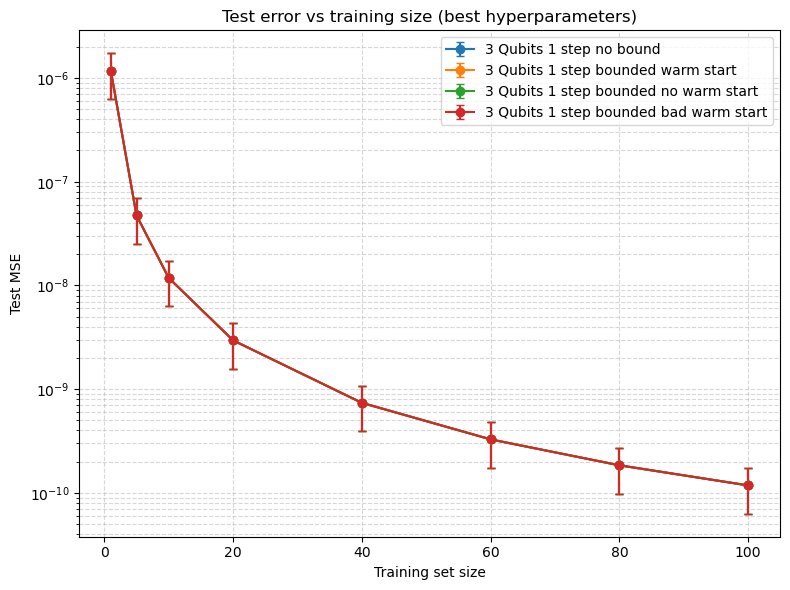

In [17]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


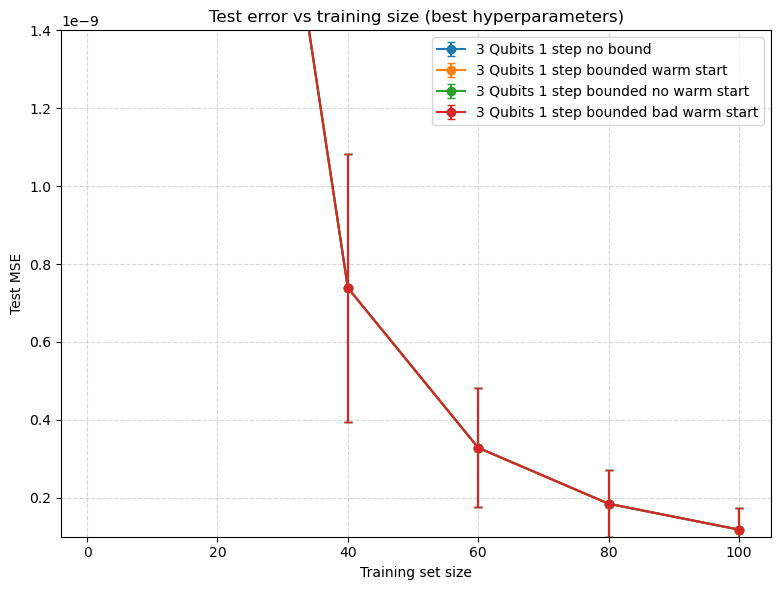

In [18]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(1e-10,1.4e-9)
plt.show()


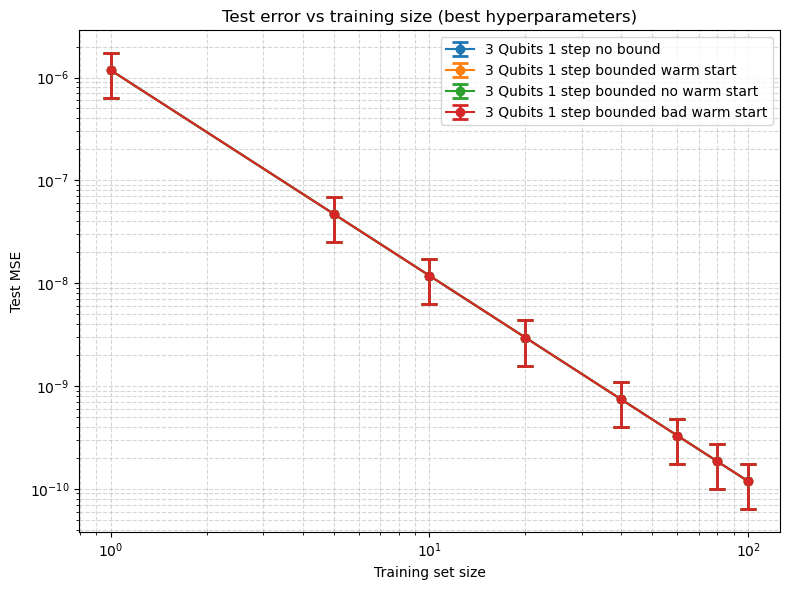

In [19]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=6,
        elinewidth=2,
        capthick=2,
        label=name
    )


plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Generalization Gap

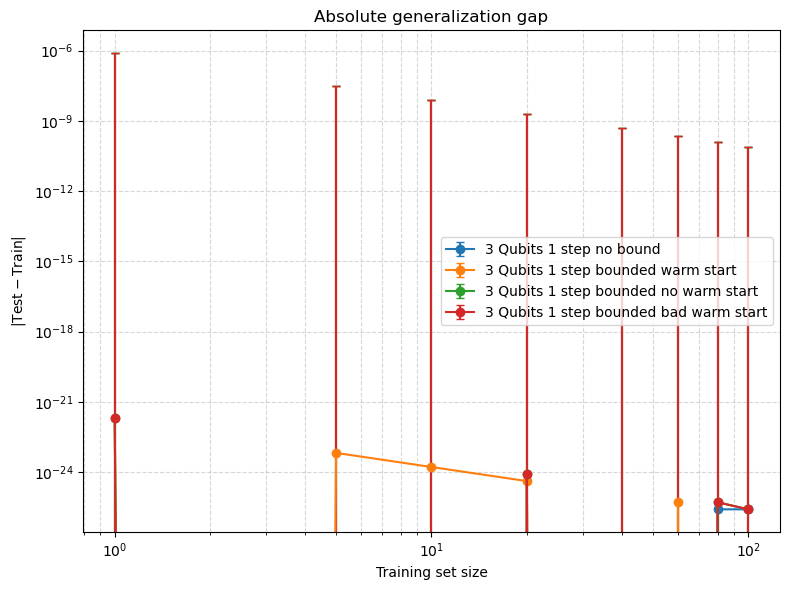

In [20]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

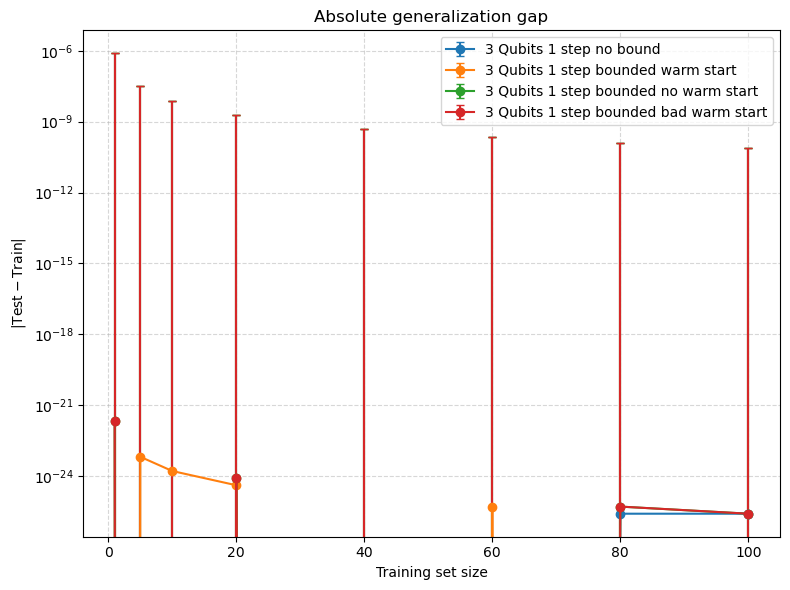

In [21]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()